# Riesgo y predicción cuantitativa: factores asociados al mal riesgo crediticio
## Statlog German Credit Data (UCI)

**Curso:** MCC002 — Probabilidad y Estadística Computacional · Periodo 2026-1
**Programa:** Maestría en Ciencia de la Computación, mención Computación Científica — FC, UNI
**Docente:** Dra. Rocío Milagros Zorrilla Coz
**Grupo N.º 5:** Armando Castro Chaupis · Henry Sánchez Alvarado · Alex Segura Núñez

---

**Pregunta de investigación central:** ¿Qué factores explican la probabilidad de que un solicitante sea clasificado como *mal riesgo crediticio*?

**Preguntas secundarias (consigna del Grupo 5):**

1. Proporción global de malos créditos y su IC 95 %.
2. ¿La tasa de mal crédito difiere según el propósito del préstamo?
3. ¿La duración y el monto del crédito difieren entre buenos y malos créditos?
4. ¿Qué variables están asociadas con mayor riesgo crediticio?
5. ¿Cómo cambia la clasificación al modificar el umbral de decisión?

El notebook sigue la secuencia del curso — **Problema real → Marco teórico → Solución algorítmica → Evaluación crítica** — repetida en cada bloque (descriptivo, inferencial, regresión y bayesiano), y cubre todos los análisis mínimos de la Sección 5 de la consigna: ajuste MLE, IC analítico, IC bootstrap, prueba de hipótesis con tamaño de efecto, regresión lineal múltiple con diagnóstico completo, validación cruzada *k*-fold, modelo bayesiano conjugado con sensibilidad al prior y sampler Metropolis–Hastings implementado desde cero.

## 1. Introducción y pregunta de investigación

**Problema real.** Una entidad financiera debe decidir si otorga o no un crédito a cada solicitante. Clasificar erróneamente a un cliente *malo* como *bueno* (otorgar un crédito que no será pagado) es mucho más costoso que rechazar a un cliente *bueno*. El propio dataset incluye una **matriz de costos asimétrica** (5 : 1) que formaliza esta asimetría y que usaremos en el análisis del umbral de decisión (§9).

**Marco teórico.** Modelamos la clase de riesgo $Y \in \{0=\text{bueno},\ 1=\text{malo}\}$ como una variable Bernoulli cuya probabilidad depende de covariables del solicitante y del crédito. El flujo combina: (i) inferencia frecuentista sobre la tasa global de mal crédito $p$ y sobre diferencias entre grupos; (ii) un modelo de **regresión logística** $\Pr(Y=1\mid \mathbf{x}) = \sigma(\mathbf{x}^\top\boldsymbol\beta)$ para identificar factores de riesgo; y (iii) un análisis **bayesiano conjugado Beta-Binomial** sobre $p$, contrastado con el resultado frecuentista, más un sampler **Metropolis–Hastings** para la posterior de un coeficiente clave del modelo logístico.

**Evaluación crítica (adelanto).** El accuracy es una métrica engañosa aquí: con 70 % de créditos buenos, un clasificador trivial que apruebe a todos alcanza 70 % de accuracy pero incurre en el máximo costo posible por falsos negativos. Por eso la evaluación se centra en ROC–AUC, precision, recall y **costo esperado** bajo la matriz 5 : 1.

## 2. Configuración del entorno y reproducibilidad

Entorno: Python ≥ 3.10 con `numpy`, `scipy`, `pandas`, `matplotlib`, `seaborn`, `statsmodels` y `scikit-learn`.
Se fija la semilla global al inicio (`numpy.random.seed`) y se registran las versiones de las librerías. El archivo `requirements.txt` acompaña al entregable.

In [ ]:
# --- Librerías y configuración global ---
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn

# Reproducibilidad: semilla global fijada al inicio (requisito de la Sección 4 de la consigna)
SEED = 2026
np.random.seed(SEED)

# Estilo de gráficos
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

print("Python      :", sys.version.split()[0])
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scipy       :", scipy.__version__)
print("statsmodels :", sm.__version__ if hasattr(sm, "__version__") else "ver requirements.txt")
print("scikit-learn:", sklearn.__version__)
print("seaborn     :", sns.__version__)

Python      : 3.12.3
numpy       : 2.4.4
pandas      : 3.0.2
scipy       : 1.17.1
statsmodels : 0.14.6
scikit-learn: 1.8.0
seaborn     : 0.13.2


## 3. Descripción, citación y carga del dataset

**Dataset principal:** *Statlog (German Credit Data)* — UCI Machine Learning Repository.

> Hofmann, H. (1994). *Statlog (German Credit Data)* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5NC77
> URL: https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data · Licencia: CC BY 4.0.

- **1000 observaciones** (solicitantes de crédito de un banco alemán) y **20 atributos predictores** (7 numéricos, 13 categóricos codificados como `Axy`), más la clase de riesgo (`1 = bueno`, `2 = malo`).
- El archivo original `german.data` está separado por espacios y **no tiene cabecera**; los nombres y significados de los atributos provienen del archivo de documentación oficial `german.doc`.
- El dataset **exige el uso de una matriz de costos**: clasificar un cliente *malo* como *bueno* cuesta **5**, y clasificar un *bueno* como *malo* cuesta **1**.

La celda siguiente intenta cargar el archivo local `data/german.data` (o `german.data` en el directorio del notebook); si no existe, lo descarga de la URL oficial de UCI y lo guarda en `data/` para dejar la descarga documentada y reproducible.

In [ ]:
import os, io, zipfile, urllib.request

UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/144/statlog+german+credit+data.zip"
CANDIDATOS = ["data/german.data", "german.data"]

ruta_datos = next((p for p in CANDIDATOS if os.path.exists(p)), None)

if ruta_datos is None:
    # Descarga documentada desde la fuente oficial (solo si no existe copia local)
    os.makedirs("data", exist_ok=True)
    print("Descargando dataset desde UCI...")
    with urllib.request.urlopen(UCI_ZIP_URL) as r:
        zf = zipfile.ZipFile(io.BytesIO(r.read()))
        zf.extract("german.data", path="data")
    ruta_datos = "data/german.data"

# Nombres de columnas según german.doc (atributos 1..20 + clase)
columnas = [
    "estado_cuenta", "duracion", "historial_credito", "proposito", "monto",
    "ahorros", "empleo_actual", "tasa_cuota", "estatus_personal_sexo",
    "otros_deudores", "anios_residencia", "propiedad", "edad",
    "otros_planes_pago", "vivienda", "n_creditos_banco", "trabajo",
    "n_dependientes", "telefono", "trabajador_extranjero", "clase",
]

df = pd.read_csv(ruta_datos, sep=" ", header=None, names=columnas)
print(f"Archivo cargado: {ruta_datos}")
print(f"Dimensiones: {df.shape[0]} observaciones x {df.shape[1]} columnas")
df.head()

Archivo cargado: data/german.data
Dimensiones: 1000 observaciones x 21 columnas


,estado_cuenta,duracion,historial_credito,proposito,monto,ahorros,empleo_actual,tasa_cuota,estatus_personal_sexo,otros_deudores,...,propiedad,edad,otros_planes_pago,vivienda,n_creditos_banco,trabajo,n_dependientes,telefono,trabajador_extranjero,clase
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


### 3.1 Diccionario de variables

Construido a partir de `german.doc`. Las 13 variables cualitativas usan códigos `Axy`; abajo se documenta el significado de cada código y se crea un mapeo a etiquetas legibles en español que se usará en los gráficos.

| # | Variable (nombre en el notebook) | Tipo | Descripción |
|---|---|---|---|
| 1 | `estado_cuenta` | Categórica ordinal | Estado de la cuenta corriente: A11 (< 0 DM), A12 (0–200 DM), A13 (≥ 200 DM), A14 (sin cuenta) |
| 2 | `duracion` | Numérica (meses) | Duración del crédito |
| 3 | `historial_credito` | Categórica | A30–A34: de "sin créditos/todo pagado" a "cuenta crítica/créditos en otros bancos" |
| 4 | `proposito` | Categórica nominal | A40–A410: auto nuevo/usado, mobiliario, radio/TV, electrodomésticos, reparaciones, educación, reentrenamiento, negocio, otros |
| 5 | `monto` | Numérica (DM) | Monto del crédito |
| 6 | `ahorros` | Categórica ordinal | A61–A65: nivel de ahorros/bonos (A65 = desconocido/sin cuenta) |
| 7 | `empleo_actual` | Categórica ordinal | A71–A75: antigüedad en el empleo actual |
| 8 | `tasa_cuota` | Numérica (1–4) | Cuota como % del ingreso disponible |
| 9 | `estatus_personal_sexo` | Categórica | A91–A94: estado civil y sexo (composición histórica del dataset) |
| 10 | `otros_deudores` | Categórica | A101 ninguno, A102 co-solicitante, A103 garante |
| 11 | `anios_residencia` | Numérica (1–4) | Años en la residencia actual |
| 12 | `propiedad` | Categórica | A121 inmueble … A124 sin propiedad conocida |
| 13 | `edad` | Numérica (años) | Edad del solicitante |
| 14 | `otros_planes_pago` | Categórica | A141 banco, A142 tiendas, A143 ninguno |
| 15 | `vivienda` | Categórica | A151 alquilada, A152 propia, A153 gratuita |
| 16 | `n_creditos_banco` | Numérica | N.º de créditos existentes en este banco |
| 17 | `trabajo` | Categórica ordinal | A171–A174: de no calificado/no residente a directivo/independiente |
| 18 | `n_dependientes` | Numérica | Personas a cargo |
| 19 | `telefono` | Binaria | A191 no, A192 sí (registrado) |
| 20 | `trabajador_extranjero` | Binaria | A201 sí, A202 no |
| 21 | `clase` | **Variable respuesta** | 1 = buen riesgo, 2 = mal riesgo |

In [3]:
# Mapeos de códigos Axy -> etiquetas legibles (según german.doc)
mapa_proposito = {
    "A40": "Auto nuevo", "A41": "Auto usado", "A42": "Mobiliario/equipos",
    "A43": "Radio/TV", "A44": "Electrodomésticos", "A45": "Reparaciones",
    "A46": "Educación", "A48": "Reentrenamiento", "A49": "Negocio", "A410": "Otros",
}
mapa_estado_cuenta = {
    "A11": "< 0 DM", "A12": "0 – 200 DM", "A13": "≥ 200 DM", "A14": "Sin cuenta",
}
mapa_ahorros = {
    "A61": "< 100 DM", "A62": "100 – 500 DM", "A63": "500 – 1000 DM",
    "A64": "≥ 1000 DM", "A65": "Desconocido/sin cuenta",
}
mapa_historial = {
    "A30": "Sin créditos/todo pagado", "A31": "Pagados en este banco",
    "A32": "Al día hasta ahora", "A33": "Retrasos en el pasado",
    "A34": "Cuenta crítica/otros bancos",
}

df["proposito_lbl"] = df["proposito"].map(mapa_proposito)
df["estado_cuenta_lbl"] = df["estado_cuenta"].map(mapa_estado_cuenta)

# Verificación de que no quedaron códigos sin mapear
assert df["proposito_lbl"].notna().all(), "Hay códigos de propósito sin mapear"
assert df["estado_cuenta_lbl"].notna().all(), "Hay códigos de estado de cuenta sin mapear"

vars_numericas = ["duracion", "monto", "tasa_cuota", "anios_residencia",
                  "edad", "n_creditos_banco", "n_dependientes"]
vars_categoricas = [c for c in columnas if c not in vars_numericas + ["clase"]]
print(f"Variables numéricas ({len(vars_numericas)}): {vars_numericas}")
print(f"Variables categóricas ({len(vars_categoricas)}): {vars_categoricas}")

Variables numéricas (7): ['duracion', 'monto', 'tasa_cuota', 'anios_residencia', 'edad', 'n_creditos_banco', 'n_dependientes']
Variables categóricas (13): ['estado_cuenta', 'historial_credito', 'proposito', 'ahorros', 'empleo_actual', 'estatus_personal_sexo', 'otros_deudores', 'propiedad', 'otros_planes_pago', 'vivienda', 'trabajo', 'telefono', 'trabajador_extranjero']


## 4. Limpieza, preprocesamiento y recodificación documentada de la variable respuesta

**Recodificación de la variable respuesta (tarea mínima obligatoria).** El archivo original codifica la clase como `1 = buen riesgo` y `2 = mal riesgo`. Para el análisis definimos:

$$Y = \texttt{mal\_credito} = \begin{cases} 1 & \text{si } \texttt{clase} = 2 \ (\text{mal riesgo, clase positiva}) \\ 0 & \text{si } \texttt{clase} = 1 \ (\text{buen riesgo}) \end{cases}$$

**Justificación:** en riesgo crediticio el evento de interés es el *incumplimiento*; codificarlo como clase positiva (1) hace que *recall* mida directamente la capacidad de detectar clientes malos y alinea el modelo con la matriz de costos (el falso negativo — mal cliente aprobado — es el error caro, costo 5).

Además se verifica: valores faltantes, duplicados, rangos válidos y consistencia de códigos. Nota: en este dataset la categoría "desconocido" de `ahorros` (A65) y "sin propiedad" (A124) **no son valores faltantes** sino categorías informativas propias del proceso de originación.

In [4]:
# --- Recodificación documentada de la variable respuesta ---
df["mal_credito"] = (df["clase"] == 2).astype(int)
df["clase_lbl"] = df["mal_credito"].map({0: "Buen riesgo", 1: "Mal riesgo"})

# --- Verificaciones de calidad de datos ---
print("Valores faltantes por columna (total):", int(df[columnas].isna().sum().sum()))
print("Filas duplicadas:", int(df.duplicated(subset=columnas).sum()))

# Rangos válidos de variables numéricas
chequeos = {
    "duracion > 0": (df["duracion"] > 0).all(),
    "monto > 0": (df["monto"] > 0).all(),
    "edad entre 18 y 100": df["edad"].between(18, 100).all(),
    "tasa_cuota en 1..4": df["tasa_cuota"].between(1, 4).all(),
    "clase en {1,2}": df["clase"].isin([1, 2]).all(),
}
for k, v in chequeos.items():
    print(f"  [{'OK' if v else 'REVISAR'}] {k}")

# Transformación: log del monto (distribución fuertemente asimétrica, ver §5 y §6)
df["log_monto"] = np.log(df["monto"])

print("\nDistribución de la variable respuesta recodificada:")
print(df["clase_lbl"].value_counts())
print(f"\nTasa global de mal crédito: {df['mal_credito'].mean():.3f}")

Valores faltantes por columna (total): 0
Filas duplicadas: 0
  [OK] duracion > 0
  [OK] monto > 0
  [OK] edad entre 18 y 100
  [OK] tasa_cuota en 1..4
  [OK] clase en {1,2}

Distribución de la variable respuesta recodificada:
clase_lbl
Buen riesgo    700
Mal riesgo     300
Name: count, dtype: int64

Tasa global de mal crédito: 0.300


**Evaluación crítica del bloque.** El dataset no tiene faltantes ni duplicados y todos los rangos son válidos, de modo que la limpieza se reduce a la recodificación documentada y a una transformación (log del monto) motivada por la asimetría que se verá en el EDA. La única decisión de preprocesamiento con impacto inferencial es tratar A65/A124 como categorías y no como faltantes; lo contrario descartaría información predictiva (la *ausencia* de cuenta de ahorros es en sí misma una señal).

## 5. Análisis exploratorio (EDA) y estadística descriptiva

**Marco teórico.** Antes de modelar necesitamos conocer: el balance de clases (afecta métricas y umbral), la forma de las distribuciones (afecta la elección de pruebas y transformaciones) y las asociaciones marginales entre predictores y la clase (candidatas a factores de riesgo).

In [5]:
# Estadística descriptiva de las variables numéricas
desc = df[vars_numericas].describe().T
desc["asimetria"] = df[vars_numericas].skew()
desc["curtosis"] = df[vars_numericas].kurtosis()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis
duracion,1000.0,20.90,12.06,4.0,12.0,18.0,24.00,72.0,1.09,0.92
monto,1000.0,3271.26,2822.74,250.0,1365.5,2319.5,3972.25,18424.0,1.95,4.29
tasa_cuota,1000.0,2.97,1.12,1.0,2.0,3.0,4.00,4.0,-0.53,-1.21
anios_residencia,1000.0,2.84,1.10,1.0,2.0,3.0,4.00,4.0,-0.27,-1.38
edad,1000.0,35.55,11.38,19.0,27.0,33.0,42.00,75.0,1.02,0.60
n_creditos_banco,1000.0,1.41,0.58,1.0,1.0,1.0,2.00,4.0,1.27,1.60
n_dependientes,1000.0,1.16,0.36,1.0,1.0,1.0,1.00,2.0,1.91,1.65


In [6]:
# Descriptivos condicionales por clase de riesgo (variables clave de la consigna)
df.groupby("clase_lbl")[["duracion", "monto", "edad", "tasa_cuota"]].agg(
    ["mean", "median", "std"]).round(2)

duracion                  monto                    edad         \
                mean median    std     mean  median      std   mean median   
clase_lbl                                                                    
Buen riesgo    19.21   18.0  11.08  2985.46  2244.0  2401.47  36.22   34.0   
Mal riesgo     24.86   24.0  13.28  3938.13  2574.5  3535.82  33.96   31.0   

                   tasa_cuota               
               std       mean median   std  
clase_lbl                                   
Buen riesgo  11.38       2.92    3.0  1.13  
Mal riesgo   11.22       3.10    4.0  1.09

In [7]:
# Tabla: tasa de mal crédito por propósito del préstamo (pregunta secundaria 2)
tasa_prop = (df.groupby("proposito_lbl")["mal_credito"]
               .agg(n="count", tasa_mal_credito="mean")
               .sort_values("tasa_mal_credito", ascending=False))
tasa_prop["tasa_mal_credito"] = tasa_prop["tasa_mal_credito"].round(3)
tasa_prop

,n,tasa_mal_credito
proposito_lbl,,
Educación,50,0.440
Otros,12,0.417
Auto nuevo,234,0.380
Reparaciones,22,0.364
Negocio,97,0.351
Electrodomésticos,12,0.333
Mobiliario/equipos,181,0.320
Radio/TV,280,0.221
Auto usado,103,0.165


**Lectura preliminar.** `monto` es fuertemente asimétrico a la derecha (asimetría ≈ 1.9), lo que motiva la transformación logarítmica y el uso de pruebas robustas (Mann–Whitney) además de Welch. Las tasas de mal crédito por propósito varían de ~11 % (reentrenamiento) a ~44 % (educación), aunque varios grupos son pequeños (n ≤ 12), lo que obliga a leer con cautela y a verificar frecuencias esperadas en la prueba χ².

## 6. Visualizaciones principales

Se presentan las figuras exigidas por la consigna del Grupo 5 (barras de la clase, tasa de mal crédito por propósito, boxplots de duración y monto por clase) más figuras de apoyo (distribución del monto con ajuste MLE en §7, matriz de correlaciones, curva ROC y matrices de confusión en §8–§9).

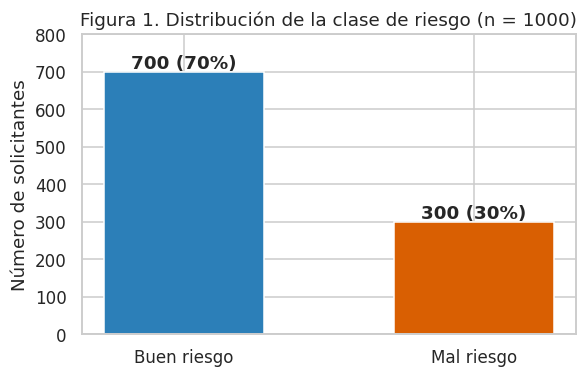

In [8]:
# Figura 1. Distribución de la clase de riesgo (balance de clases)
fig, ax = plt.subplots(figsize=(5.5, 3.6))
conteo = df["clase_lbl"].value_counts().reindex(["Buen riesgo", "Mal riesgo"])
bars = ax.bar(conteo.index, conteo.values, color=["#2c7fb8", "#d95f02"], width=0.55)
for b, v in zip(bars, conteo.values):
    ax.text(b.get_x() + b.get_width()/2, v + 8, f"{v} ({v/len(df):.0%})",
            ha="center", fontweight="bold")
ax.set_ylabel("Número de solicitantes")
ax.set_title("Figura 1. Distribución de la clase de riesgo (n = 1000)")
ax.set_ylim(0, 800)
plt.tight_layout(); plt.show()

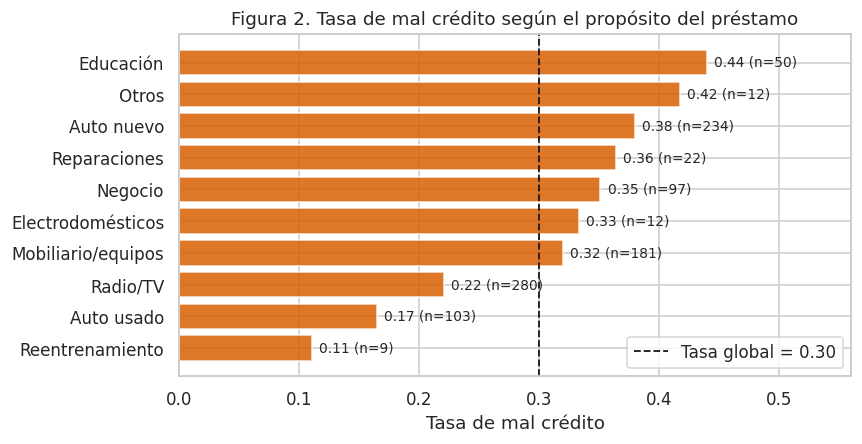

In [9]:
# Figura 2. Tasa de mal crédito por propósito del préstamo
fig, ax = plt.subplots(figsize=(8, 4.2))
orden = tasa_prop.sort_values("tasa_mal_credito").index
ax.barh(orden, tasa_prop.loc[orden, "tasa_mal_credito"], color="#d95f02", alpha=0.85)
ax.axvline(df["mal_credito"].mean(), color="k", ls="--", lw=1.2,
           label=f"Tasa global = {df['mal_credito'].mean():.2f}")
for y, prop in enumerate(orden):
    n = tasa_prop.loc[prop, "n"]
    t = tasa_prop.loc[prop, "tasa_mal_credito"]
    ax.text(t + 0.006, y, f"{t:.2f} (n={n})", va="center", fontsize=9)
ax.set_xlabel("Tasa de mal crédito")
ax.set_title("Figura 2. Tasa de mal crédito según el propósito del préstamo")
ax.set_xlim(0, 0.56); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

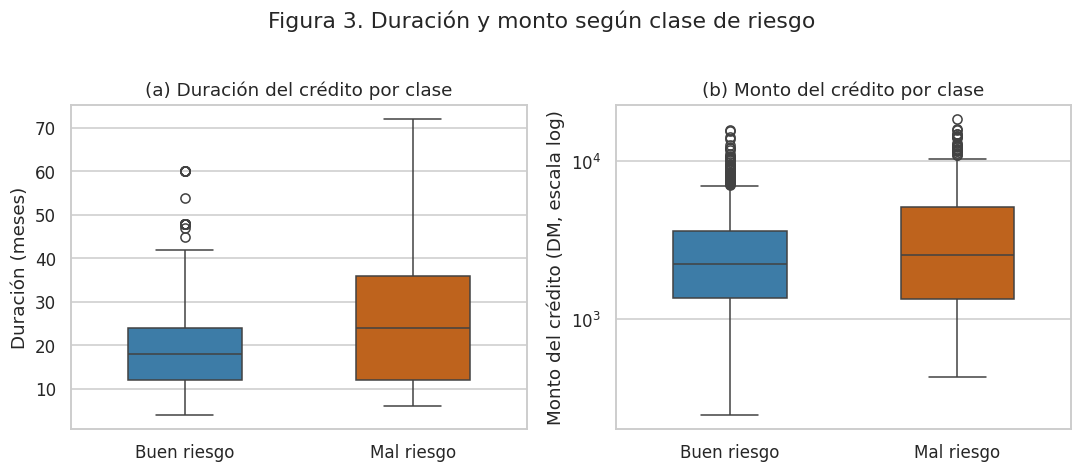

In [10]:
# Figura 3. Duración y monto del crédito por clase de riesgo (boxplots)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
sns.boxplot(data=df, x="clase_lbl", y="duracion", hue="clase_lbl", ax=axes[0],
            palette=["#2c7fb8", "#d95f02"], width=0.5, legend=False)
axes[0].set_xlabel(""); axes[0].set_ylabel("Duración (meses)")
axes[0].set_title("(a) Duración del crédito por clase")
sns.boxplot(data=df, x="clase_lbl", y="monto", hue="clase_lbl", ax=axes[1],
            palette=["#2c7fb8", "#d95f02"], width=0.5, legend=False)
axes[1].set_yscale("log")
axes[1].set_xlabel(""); axes[1].set_ylabel("Monto del crédito (DM, escala log)")
axes[1].set_title("(b) Monto del crédito por clase")
fig.suptitle("Figura 3. Duración y monto según clase de riesgo", y=1.02)
plt.tight_layout(); plt.show()

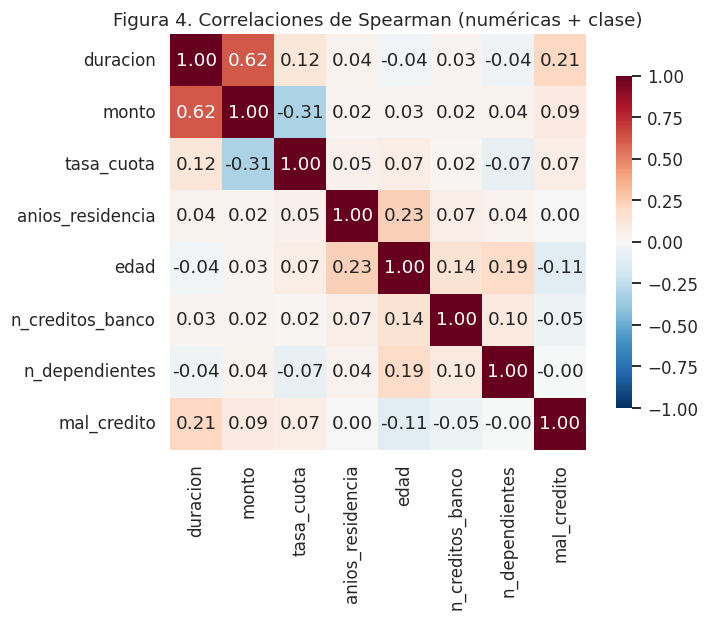

In [11]:
# Figura 4. Matriz de correlaciones (Spearman) entre variables numéricas y la clase
corr = df[vars_numericas + ["mal_credito"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7.2, 5.8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Figura 4. Correlaciones de Spearman (numéricas + clase)")
plt.tight_layout(); plt.show()

**Lectura de las figuras.** (1) El dataset está **desbalanceado 70/30**; no severamente, pero lo suficiente para invalidar el accuracy como métrica única. (2) Educación, "otros" y auto nuevo superan la tasa global de mal crédito; auto usado y reentrenamiento están claramente por debajo. (3) Los malos créditos tienden a ser **más largos** y de **mayor monto** (la mediana de duración pasa de 18 a 24 meses). (4) `duracion` y `monto` están fuertemente correlacionados entre sí (ρ ≈ 0.62), lo que anticipa colinealidad moderada en la regresión; ambas se asocian positivamente con `mal_credito`.

## 7. Ajuste paramétrico por máxima verosimilitud (MLE)

**Marco teórico.** El monto del crédito es positivo y fuertemente asimétrico; dos familias candidatas naturales son la **Lognormal** y la **Gamma**. Ajustamos ambas por MLE con `scipy.stats.<dist>.fit()` (fijando `loc = 0`, pues el soporte es $(0,\infty)$) y comparamos mediante log-verosimilitud, AIC y QQ-plot.

Para $X \sim \mathrm{Lognormal}(\mu, \sigma)$, el MLE tiene forma cerrada: $\hat\mu = \overline{\log x}$, $\hat\sigma^2 = \widehat{\mathrm{Var}}(\log x)$; verificamos que `scipy` reproduce ese resultado.

In [12]:
x = df["monto"].values

# Ajuste MLE de dos familias candidatas (loc fijado en 0: soporte positivo)
par_ln = stats.lognorm.fit(x, floc=0)     # (shape=sigma, loc, scale=exp(mu))
par_ga = stats.gamma.fit(x, floc=0)       # (shape=k, loc, scale=theta)

# Log-verosimilitud y AIC (2 parámetros libres en cada caso)
ll_ln = np.sum(stats.lognorm.logpdf(x, *par_ln))
ll_ga = np.sum(stats.gamma.logpdf(x, *par_ga))
aic = lambda ll, k=2: 2*k - 2*ll

print(f"Lognormal: sigma={par_ln[0]:.4f}, mu=log(scale)={np.log(par_ln[2]):.4f} | "
      f"logL={ll_ln:.1f} | AIC={aic(ll_ln):.1f}")
print(f"Gamma    : k={par_ga[0]:.4f}, theta={par_ga[2]:.1f} | "
      f"logL={ll_ga:.1f} | AIC={aic(ll_ga):.1f}")

# Verificación del MLE cerrado de la lognormal
mu_hat, sigma_hat = np.log(x).mean(), np.log(x).std(ddof=0)
print(f"\nVerificación forma cerrada: mu={mu_hat:.4f}, sigma={sigma_hat:.4f} "
      f"(coincide con scipy: {np.isclose(mu_hat, np.log(par_ln[2]), atol=1e-3) and np.isclose(sigma_hat, par_ln[0], atol=1e-3)})")

Lognormal: sigma=0.7761, mu=log(scale)=7.7887 | logL=-8954.1 | AIC=17912.3
Gamma    : k=1.7921, theta=1825.4 | logL=-9007.2 | AIC=18018.4

Verificación forma cerrada: mu=7.7887, sigma=0.7761 (coincide con scipy: True)


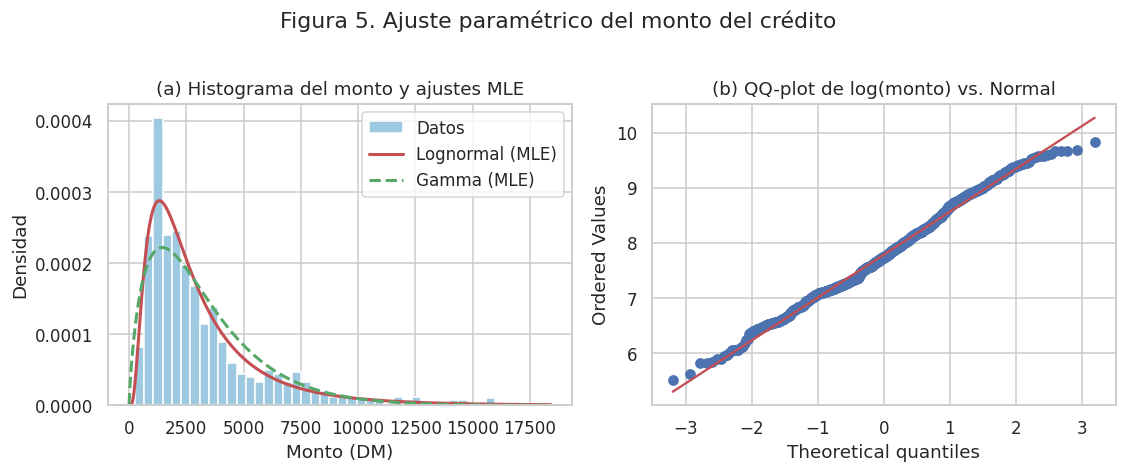

In [13]:
# Figura 5. Ajuste MLE del monto: histograma + densidades y QQ-plot lognormal
grid = np.linspace(1, x.max(), 600)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].hist(x, bins=45, density=True, color="#9ecae1", edgecolor="white", label="Datos")
axes[0].plot(grid, stats.lognorm.pdf(grid, *par_ln), "r-", lw=2, label="Lognormal (MLE)")
axes[0].plot(grid, stats.gamma.pdf(grid, *par_ga), "g--", lw=2, label="Gamma (MLE)")
axes[0].set_xlabel("Monto (DM)"); axes[0].set_ylabel("Densidad")
axes[0].set_title("(a) Histograma del monto y ajustes MLE"); axes[0].legend()

stats.probplot(np.log(x), dist="norm", plot=axes[1])
axes[1].set_title("(b) QQ-plot de log(monto) vs. Normal")
fig.suptitle("Figura 5. Ajuste paramétrico del monto del crédito", y=1.02)
plt.tight_layout(); plt.show()

**Evaluación crítica.** La Lognormal domina a la Gamma en log-verosimilitud/AIC y el QQ-plot de $\log(\text{monto})$ es aproximadamente lineal salvo colas leves. Esto **justifica formalmente** usar `log_monto` como variable de trabajo en la regresión OLS (§10, donde el supuesto de normalidad se aplica a los residuales) y como predictor en la logística (§11), y explica por qué en §9 acompañamos la prueba de Welch con Mann–Whitney para el monto sin transformar.

## 8. Incertidumbre frecuentista: intervalos de confianza

**Pregunta secundaria 1: proporción global de malos créditos y su IC 95 %.**

**Marco teórico.** Sea $X = \sum Y_i \sim \mathrm{Bin}(n, p)$ el número de malos créditos. Reportamos:

1. **IC analítico de Wilson** (exigido por la consigna), que invierte el estadístico *z* score:
$$\frac{\hat p + \frac{z^2}{2n} \pm z\sqrt{\frac{\hat p(1-\hat p)}{n} + \frac{z^2}{4n^2}}}{1 + z^2/n}$$
Es preferible al intervalo de Wald porque su cobertura real se mantiene cerca del 95 % incluso con $p$ alejado de 0.5 o $n$ moderado.
2. **IC por bootstrap no paramétrico** (percentil, $B = 10\,000$ remuestras), que no asume forma distribucional.
3. Como IC analítico adicional de tipo *t*, un intervalo para la **media de la duración** de los créditos.

In [14]:
n = len(df)
x_mal = int(df["mal_credito"].sum())
p_hat = x_mal / n
z = stats.norm.ppf(0.975)

# (1) IC de Wilson (analítico, tipo z)
denom = 1 + z**2 / n
centro = (p_hat + z**2 / (2*n)) / denom
medio  = z * np.sqrt(p_hat*(1-p_hat)/n + z**2/(4*n**2)) / denom
ic_wilson = (centro - medio, centro + medio)

# Verificación con statsmodels
from statsmodels.stats.proportion import proportion_confint
ic_wilson_sm = proportion_confint(x_mal, n, alpha=0.05, method="wilson")

# (2) IC bootstrap percentil para la proporción (B = 10 000)
B = 10_000
rng = np.random.default_rng(SEED)
boot_p = rng.choice(df["mal_credito"].values, size=(B, n), replace=True).mean(axis=1)
ic_boot = tuple(np.percentile(boot_p, [2.5, 97.5]))

# (3) IC t analítico para la media de la duración
dur = df["duracion"]
ic_t_dur = stats.t.interval(0.95, df=n-1, loc=dur.mean(), scale=dur.sem())

print(f"x = {x_mal} malos créditos de n = {n};  p_hat = {p_hat:.3f}")
print(f"IC 95% Wilson (manual)      : ({ic_wilson[0]:.4f}, {ic_wilson[1]:.4f})")
print(f"IC 95% Wilson (statsmodels) : ({ic_wilson_sm[0]:.4f}, {ic_wilson_sm[1]:.4f})")
print(f"IC 95% bootstrap percentil  : ({ic_boot[0]:.4f}, {ic_boot[1]:.4f})   [B = {B}]")
print(f"\nIC 95% t para la media de duración: ({ic_t_dur[0]:.2f}, {ic_t_dur[1]:.2f}) meses "
      f"(media = {dur.mean():.2f})")

x = 300 malos créditos de n = 1000;  p_hat = 0.300
IC 95% Wilson (manual)      : (0.2724, 0.3291)
IC 95% Wilson (statsmodels) : (0.2724, 0.3291)
IC 95% bootstrap percentil  : (0.2720, 0.3290)   [B = 10000]

IC 95% t para la media de duración: (20.15, 21.65) meses (media = 20.90)


**Respuesta a la pregunta 1.** La proporción global de malos créditos es $\hat p = 0.300$, con IC 95 % de Wilson $\approx (0.272,\ 0.329)$. El bootstrap coincide casi exactamente, lo esperable con $n = 1000$ y $\hat p$ lejos de los bordes. **Advertencia de validez externa:** este dataset fue construido con *sobremuestreo* de malos créditos respecto a una cartera real (donde el incumplimiento suele ser < 10 %), de modo que $p$ describe a *esta muestra*, no a la población bancaria general — limitación retomada en §13 y en el prior informativo bayesiano (§12).

## 9. Inferencia frecuentista: pruebas de hipótesis con tamaño de efecto

### 9.1 ¿La tasa de mal crédito difiere según el propósito? (pregunta secundaria 2)

Prueba $\chi^2$ de independencia sobre la tabla clase × propósito, con **V de Cramér** como tamaño de efecto:
$$V = \sqrt{\frac{\chi^2}{n \cdot \min(r-1, c-1)}}$$
Se verifica la condición de frecuencias esperadas ≥ 5 y, como robustez, se repite la prueba agrupando los propósitos con $n < 30$ en una categoría "Otros (agrupado)".

In [15]:
tabla = pd.crosstab(df["proposito_lbl"], df["mal_credito"])
chi2, p_chi, dof, esperadas = stats.chi2_contingency(tabla)
V = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
n_esp_bajas = int((esperadas < 5).sum())

print("--- Prueba chi-cuadrado: clase x propósito (10 categorías) ---")
print(f"chi2 = {chi2:.2f}, gl = {dof}, p = {p_chi:.5f}, V de Cramér = {V:.3f}")
print(f"Celdas con frecuencia esperada < 5: {n_esp_bajas} de {tabla.size}")

# Robustez: agrupar propósitos con n < 30 (Electrodomésticos, Otros, Reparaciones, Reentrenamiento)
frec = df["proposito_lbl"].value_counts()
raros = frec[frec < 30].index.tolist()
df["proposito_grp"] = df["proposito_lbl"].where(~df["proposito_lbl"].isin(raros),
                                                "Otros (agrupado)")
tabla_g = pd.crosstab(df["proposito_grp"], df["mal_credito"])
chi2_g, p_g, dof_g, esp_g = stats.chi2_contingency(tabla_g)
V_g = np.sqrt(chi2_g / (n * (min(tabla_g.shape) - 1)))
print(f"\n--- Robustez con categorías raras agrupadas ({tabla_g.shape[0]} categorías) ---")
print(f"Agrupados: {raros}")
print(f"chi2 = {chi2_g:.2f}, gl = {dof_g}, p = {p_g:.5f}, V de Cramér = {V_g:.3f}, "
      f"esperadas < 5: {int((esp_g < 5).sum())}")

--- Prueba chi-cuadrado: clase x propósito (10 categorías) ---
chi2 = 33.36, gl = 9, p = 0.00012, V de Cramér = 0.183
Celdas con frecuencia esperada < 5: 3 de 20

--- Robustez con categorías raras agrupadas (7 categorías) ---
Agrupados: ['Reparaciones', 'Electrodomésticos', 'Otros', 'Reentrenamiento']
chi2 = 30.76, gl = 6, p = 0.00003, V de Cramér = 0.175, esperadas < 5: 0


### 9.2 ¿Difieren la duración y el monto entre buenos y malos créditos? (pregunta secundaria 3)

- **Duración:** prueba **t de Welch** (no asume varianzas iguales) con **d de Cohen** (desviación estándar agrupada).
- **Monto:** por la fuerte asimetría documentada en §7, prueba **U de Mann–Whitney** con la **correlación biserial de rangos** $r = 1 - \frac{2U}{n_1 n_2}$ como tamaño de efecto, acompañada de la d de Cohen sobre $\log(\text{monto})$ para tener una magnitud comparable.

In [16]:
buenos = df[df["mal_credito"] == 0]
malos  = df[df["mal_credito"] == 1]

def d_cohen(a, b):
    s_pool = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / s_pool

# --- Duración: Welch + d de Cohen ---
t_w, p_w = stats.ttest_ind(malos["duracion"], buenos["duracion"], equal_var=False)
d_dur = d_cohen(malos["duracion"], buenos["duracion"])
print("--- Duración (meses): Welch ---")
print(f"media buenos = {buenos['duracion'].mean():.2f} | media malos = {malos['duracion'].mean():.2f}")
print(f"t = {t_w:.3f}, p = {p_w:.2e}, d de Cohen = {d_dur:.3f} (efecto mediano)")

# --- Monto: Mann-Whitney + tamaños de efecto ---
U, p_u = stats.mannwhitneyu(malos["monto"], buenos["monto"], alternative="two-sided")
r_rb = 1 - 2*U/(len(malos)*len(buenos))          # correlación biserial de rangos
d_logm = d_cohen(malos["log_monto"], buenos["log_monto"])
print("\n--- Monto (DM): Mann-Whitney ---")
print(f"mediana buenos = {buenos['monto'].median():.0f} | mediana malos = {malos['monto'].median():.0f}")
print(f"U = {U:.0f}, p = {p_u:.4f}, r biserial de rangos = {r_rb:.3f}, "
      f"d de Cohen sobre log(monto) = {d_logm:.3f}")

--- Duración (meses): Welch ---
media buenos = 19.21 | media malos = 24.86
t = 6.470, p = 2.40e-10, d de Cohen = 0.480 (efecto mediano)

--- Monto (DM): Mann-Whitney ---
mediana buenos = 2244 | mediana malos = 2574
U = 116520, p = 0.0059, r biserial de rangos = -0.110, d de Cohen sobre log(monto) = 0.240


**Respuestas a las preguntas 2 y 3.**

- **Propósito:** se rechaza la independencia ($\chi^2 = 33.4$, gl = 9, $p \approx 1.2\times10^{-4}$); la asociación se mantiene al agrupar categorías raras. El tamaño de efecto es **pequeño** (V ≈ 0.18): el propósito discrimina, pero por sí solo explica poco.
- **Duración:** los malos créditos duran en promedio ~5.3 meses más (24.9 vs. 19.2; $p \approx 2\times10^{-10}$), con **d ≈ 0.48** (efecto mediano). Es la diferencia univariada más clara.
- **Monto:** los malos créditos tienen montos mayores (mediana 2574 vs. 2244 DM; Mann–Whitney $p \approx 0.006$), pero el efecto es **pequeño** (d sobre log-monto ≈ 0.24). La dirección negativa de $r$ biserial refleja únicamente la convención de orden de la U.

**Evaluación crítica.** Estas son asociaciones *marginales*: duración y monto están correlacionados entre sí (ρ ≈ 0.62), por lo que la atribución de riesgo a cada factor exige el análisis condicional de la regresión logística (§11).

## 10. Regresión lineal múltiple con diagnóstico completo

**Problema real.** Además de clasificar el riesgo, a la entidad le interesa entender la *estructura* del crédito: ¿qué determina el tamaño (monto) de un préstamo? Este bloque cumple el requisito de **OLS múltiple con `statsmodels`** sobre una respuesta continua apropiada, con los 4 diagnósticos canónicos, un test formal de supuestos y validación cruzada *k*-fold.

**Modelo.** Con la justificación distribucional de §7:
$$\log(\text{monto}_i) = \beta_0 + \beta_1\,\text{duracion}_i + \beta_2\,\text{tasa\_cuota}_i + \beta_3\,\text{edad}_i + \varepsilon_i,\qquad \varepsilon_i \sim \mathcal N(0, \sigma^2)$$

`tasa_cuota` (cuota como % del ingreso) captura la restricción presupuestaria: a ingreso dado, una cuota mayor en proporción permite financiar montos mayores o refleja mayor esfuerzo financiero.

In [17]:
modelo_ols = smf.ols("log_monto ~ duracion + tasa_cuota + edad", data=df).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_monto   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     386.4
Date:                Tue, 07 Jul 2026   Prob (F-statistic):          2.04e-166
Time:                        23:32:50   Log-Likelihood:                -779.47
No. Observations:                1000   AIC:                             1567.
Df Residuals:                     996   BIC:                             1587.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.4860      0.074    100.915      0.0

In [18]:
# Colinealidad: factores de inflación de la varianza (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = sm.add_constant(df[["duracion", "tasa_cuota", "edad"]])
vifs = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])],
    index=["duracion", "tasa_cuota", "edad"], name="VIF")
print(vifs.round(3))

duracion      1.007
tasa_cuota    1.009
edad          1.005
Name: VIF, dtype: float64


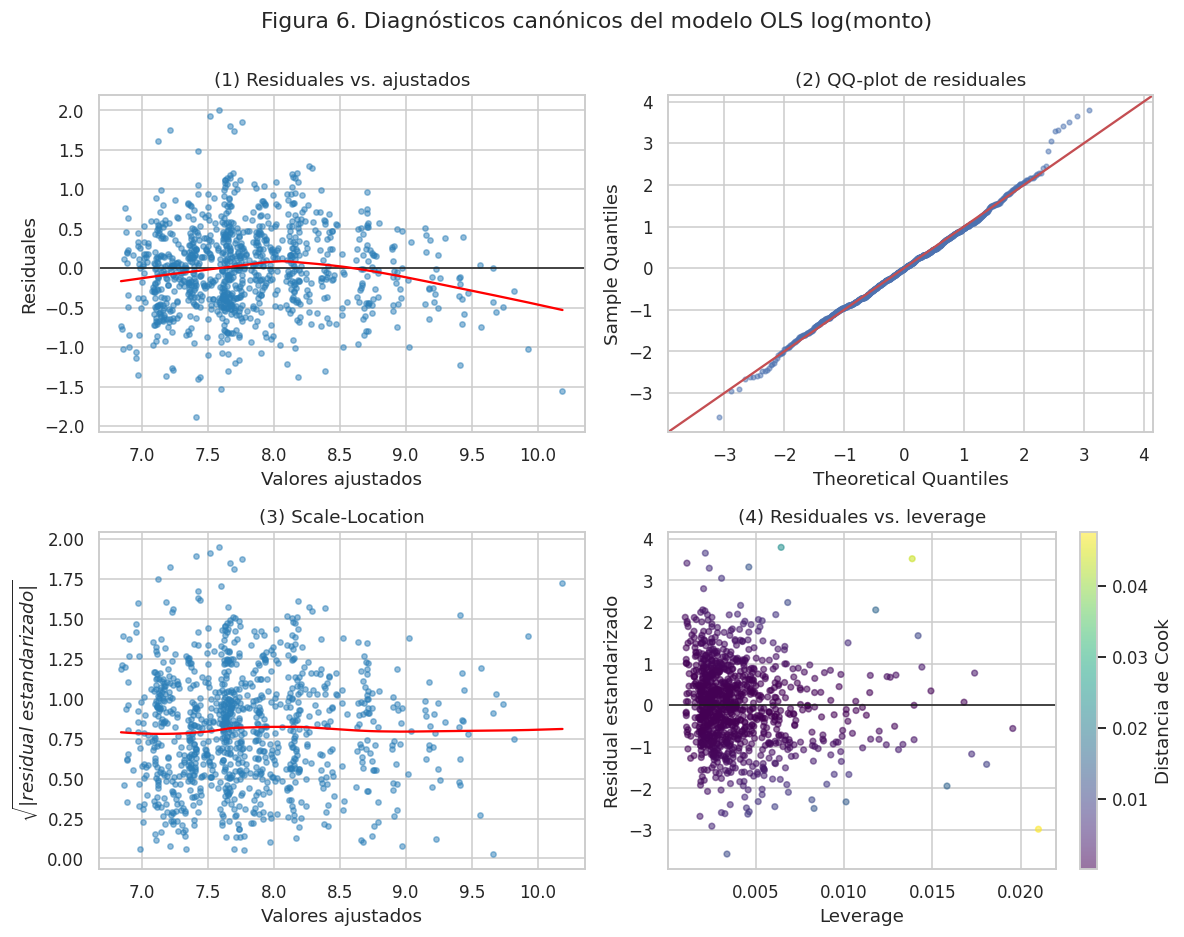

Distancia de Cook máxima: 0.0476 (umbral de alarma habitual: 1)


In [19]:
# Figura 6. Los 4 plots diagnósticos canónicos del modelo OLS
infl = modelo_ols.get_influence()
resid = modelo_ols.resid
fitted = modelo_ols.fittedvalues
resid_std = infl.resid_studentized_internal
leverage = infl.hat_matrix_diag

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))

# (1) Residuales vs. ajustados
axes[0, 0].scatter(fitted, resid, s=12, alpha=0.5, color="#2c7fb8")
axes[0, 0].axhline(0, color="k", lw=1)
sns.regplot(x=fitted, y=resid, lowess=True, scatter=False,
            line_kws={"color": "red", "lw": 1.5}, ax=axes[0, 0])
axes[0, 0].set_xlabel("Valores ajustados"); axes[0, 0].set_ylabel("Residuales")
axes[0, 0].set_title("(1) Residuales vs. ajustados")

# (2) QQ-plot de residuales
sm.qqplot(resid, line="45", fit=True, ax=axes[0, 1], markersize=3, alpha=0.5)
axes[0, 1].set_title("(2) QQ-plot de residuales")

# (3) Scale-location
axes[1, 0].scatter(fitted, np.sqrt(np.abs(resid_std)), s=12, alpha=0.5, color="#2c7fb8")
sns.regplot(x=fitted, y=np.sqrt(np.abs(resid_std)), lowess=True, scatter=False,
            line_kws={"color": "red", "lw": 1.5}, ax=axes[1, 0])
axes[1, 0].set_xlabel("Valores ajustados")
axes[1, 0].set_ylabel(r"$\sqrt{|residual\ estandarizado|}$")
axes[1, 0].set_title("(3) Scale-Location")

# (4) Residuales vs. leverage (con distancia de Cook)
cooks = infl.cooks_distance[0]
sc = axes[1, 1].scatter(leverage, resid_std, s=14, alpha=0.55, c=cooks, cmap="viridis")
axes[1, 1].axhline(0, color="k", lw=1)
axes[1, 1].set_xlabel("Leverage"); axes[1, 1].set_ylabel("Residual estandarizado")
axes[1, 1].set_title("(4) Residuales vs. leverage")
plt.colorbar(sc, ax=axes[1, 1], label="Distancia de Cook")

fig.suptitle("Figura 6. Diagnósticos canónicos del modelo OLS log(monto)", y=1.0)
plt.tight_layout(); plt.show()

print(f"Distancia de Cook máxima: {cooks.max():.4f} (umbral de alarma habitual: 1)")

In [20]:
# Tests formales de supuestos: Breusch-Pagan (homocedasticidad) y Shapiro-Wilk (normalidad)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_p, _, _ = het_breuschpagan(resid, modelo_ols.model.exog)
sw_stat, sw_p = stats.shapiro(resid)
print(f"Breusch-Pagan: LM = {bp_stat:.2f}, p = {bp_p:.4f}  "
      f"-> {'se rechaza homocedasticidad' if bp_p < 0.05 else 'no se rechaza homocedasticidad'}")
print(f"Shapiro-Wilk : W  = {sw_stat:.4f}, p = {sw_p:.4f}  "
      f"-> {'se rechaza normalidad' if sw_p < 0.05 else 'no se rechaza normalidad'}")

# Errores estándar robustos (HC3) como corrección ante heterocedasticidad
modelo_hc3 = modelo_ols.get_robustcov_results(cov_type="HC3")
tabla_ee = pd.DataFrame({
    "coef": modelo_ols.params,
    "EE clásico": modelo_ols.bse,
    "EE robusto HC3": modelo_hc3.bse,
})
print("\nComparación de errores estándar (clásicos vs. robustos):")
print(tabla_ee.round(4))

Breusch-Pagan: LM = 5.89, p = 0.1172  -> no se rechaza homocedasticidad
Shapiro-Wilk : W  = 0.9951, p = 0.0027  -> se rechaza normalidad

Comparación de errores estándar (clásicos vs. robustos):
              coef  EE clásico  EE robusto HC3
Intercept   7.4860      0.0742          0.0748
duracion    0.0431      0.0014          0.0015
tasa_cuota -0.2476      0.0150          0.0156
edad        0.0039      0.0015          0.0016


In [21]:
# Validación cruzada k-fold (k = 5) del modelo OLS
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X_ols = df[["duracion", "tasa_cuota", "edad"]].values
y_ols = df["log_monto"].values
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

resultados_cv = []
for k, (i_tr, i_te) in enumerate(kf.split(X_ols), start=1):
    reg = LinearRegression().fit(X_ols[i_tr], y_ols[i_tr])
    pred = reg.predict(X_ols[i_te])
    resultados_cv.append({
        "fold": k,
        "R2": r2_score(y_ols[i_te], pred),
        "RMSE": np.sqrt(mean_squared_error(y_ols[i_te], pred)),
    })
cv_ols = pd.DataFrame(resultados_cv).set_index("fold")
print(cv_ols.round(4))
print(f"\nR2 medio = {cv_ols['R2'].mean():.4f} ± {cv_ols['R2'].std():.4f} | "
      f"RMSE medio = {cv_ols['RMSE'].mean():.4f} (log-DM)")
print(f"R2 in-sample del modelo completo: {modelo_ols.rsquared:.4f} "
      "(similar al CV: no hay sobreajuste)")

          R2    RMSE
fold                
1     0.5321  0.5776
2     0.4972  0.5292
3     0.5943  0.4959
4     0.5439  0.4861
5     0.4901  0.5561

R2 medio = 0.5315 ± 0.0418 | RMSE medio = 0.5290 (log-DM)
R2 in-sample del modelo completo: 0.5379 (similar al CV: no hay sobreajuste)


**Evaluación crítica del bloque OLS.** El modelo explica ≈ 54 % de la varianza de $\log(\text{monto})$, estable bajo validación cruzada (R² CV ≈ 0.53 ≈ R² in-sample ⇒ sin sobreajuste). La duración domina ($\hat\beta_1 \approx 0.043$: cada mes adicional se asocia con ~4.4 % más de monto, manteniendo lo demás constante) y la tasa de cuota tiene signo negativo (a mayor % del ingreso comprometido, montos menores). El VIF ≈ 1 descarta colinealidad *dentro de este modelo*. En los diagnósticos: (1) residuales vs. ajustados sin patrón sistemático fuerte; (2) el QQ-plot muestra colas leves y Shapiro–Wilk rechaza la normalidad estricta ($p \approx 0.003$) — habitual con $n = 1000$, donde el test detecta desviaciones mínimas sin relevancia práctica; (3) el scale-location es aproximadamente plano y **Breusch–Pagan no rechaza la homocedasticidad** ($p \approx 0.12$); (4) ninguna observación supera el umbral de la distancia de Cook. Como verificación adicional, los errores estándar robustos HC3 son casi idénticos a los clásicos, de modo que la inferencia no depende del supuesto de varianza constante. Con $n = 1000$ y el CLT, los IC de los coeficientes son fiables pese a la no-normalidad estricta de los residuales.

## 11. Regresión logística: factores asociados al mal riesgo crediticio (pregunta secundaria 4)

**Marco teórico.** Modelamos
$$\Pr(Y_i = 1 \mid \mathbf x_i) = \sigma(\mathbf x_i^\top \boldsymbol\beta) = \frac{1}{1 + e^{-\mathbf x_i^\top \boldsymbol\beta}}$$
Cada $e^{\beta_j}$ es un **odds ratio (OR)**: el factor multiplicativo sobre las *odds* de mal crédito por unidad del predictor $j$, manteniendo el resto constante. Se seleccionan predictores con justificación de negocio y respaldo del EDA: estado de la cuenta corriente, duración, log(monto), historial crediticio, ahorros, antigüedad laboral, tasa de cuota, edad, vivienda y otros planes de pago.

**Protocolo de evaluación.** Partición estratificada 70/30 entrenamiento/prueba (la estratificación preserva el 30 % de malos créditos en ambas particiones). El modelo se ajusta **solo con entrenamiento** y todas las métricas de §11–§9 se reportan sobre **prueba**; adicionalmente, AUC por validación cruzada estratificada de 5 folds como chequeo de estabilidad.

In [ ]:
from sklearn.model_selection import train_test_split

FORMULA_LOGIT = ("mal_credito ~ C(estado_cuenta) + duracion + log_monto"
                 " + C(historial_credito) + C(ahorros) + C(empleo_actual)"
                 " + tasa_cuota + edad + C(vivienda) + C(otros_planes_pago)")

df_train, df_test = train_test_split(df, test_size=0.30, random_state=SEED,
                                     stratify=df["mal_credito"])
print(f"Entrenamiento: {len(df_train)} obs. (tasa mal crédito = {df_train['mal_credito'].mean():.3f})")
print(f"Prueba       : {len(df_test)} obs. (tasa mal crédito = {df_test['mal_credito'].mean():.3f})")

modelo_logit = smf.logit(FORMULA_LOGIT, data=df_train).fit(disp=0)

### revisar el pseudo-r2
print(f"\nPseudo-R2 de McFadden (train): {modelo_logit.prsquared:.4f}")
print(f"Convergencia: {modelo_logit.mle_retvals['converged']}")

Entrenamiento: 700 obs. (tasa mal crédito = 0.300)
Prueba       : 300 obs. (tasa mal crédito = 0.300)

Pseudo-R2 de McFadden (train): 0.2202
Convergencia: True


In [23]:
# Odds ratios con IC 95% (referencias: A11 '< 0 DM', A30, A61, A71, A141, A151)
or_tabla = pd.DataFrame({
    "OR": np.exp(modelo_logit.params),
    "IC 2.5%": np.exp(modelo_logit.conf_int()[0]),
    "IC 97.5%": np.exp(modelo_logit.conf_int()[1]),
    "p-valor": modelo_logit.pvalues,
}).drop(index="Intercept").sort_values("OR")
or_tabla.round(4)

,OR,IC 2.5%,IC 97.5%,p-valor
C(ahorros)[T.A64],0.1617,0.0349,0.7495,0.0199
C(estado_cuenta)[T.A14],0.1803,0.1079,0.3014,0.0000
C(historial_credito)[T.A34],0.2413,0.0910,0.6403,0.0043
C(estado_cuenta)[T.A13],0.3121,0.1384,0.7038,0.0050
C(empleo_actual)[T.A74],0.4037,0.1632,0.9987,0.0497
C(ahorros)[T.A65],0.4303,0.2421,0.7647,0.0041
C(historial_credito)[T.A33],0.4360,0.1506,1.2617,0.1257
C(historial_credito)[T.A32],0.4765,0.1893,1.1990,0.1154
C(ahorros)[T.A63],0.4809,0.1972,1.1731,0.1076
C(vivienda)[T.A152],0.5868,0.3552,0.9694,0.0374


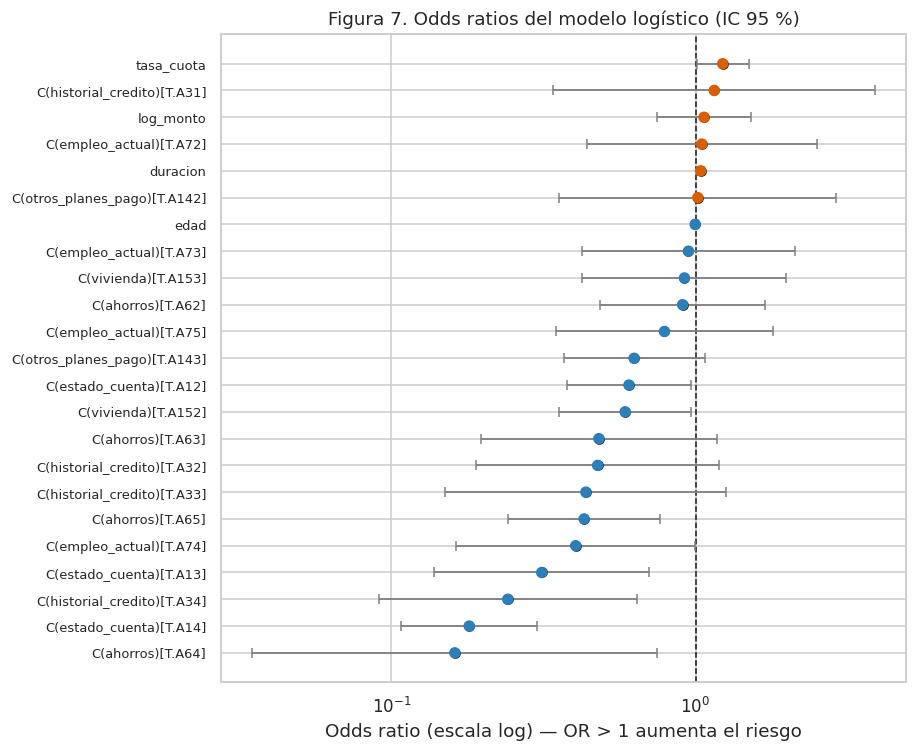

In [24]:
# Figura 7. Odds ratios con IC 95% (escala log): factores de riesgo y de protección
fig, ax = plt.subplots(figsize=(8.5, 7))
tab = or_tabla.sort_values("OR")
colores = ["#2c7fb8" if o < 1 else "#d95f02" for o in tab["OR"]]
ax.errorbar(tab["OR"], range(len(tab)),
            xerr=[tab["OR"] - tab["IC 2.5%"], tab["IC 97.5%"] - tab["OR"]],
            fmt="o", ecolor="gray", elinewidth=1.2, capsize=3,
            markerfacecolor="white", markeredgecolor="k", zorder=3)
ax.scatter(tab["OR"], range(len(tab)), c=colores, s=42, zorder=4)
ax.axvline(1, color="k", ls="--", lw=1)
ax.set_yticks(range(len(tab))); ax.set_yticklabels(tab.index, fontsize=8.5)
ax.set_xscale("log")
ax.set_xlabel("Odds ratio (escala log) — OR > 1 aumenta el riesgo")
ax.set_title("Figura 7. Odds ratios del modelo logístico (IC 95 %)")
plt.tight_layout(); plt.show()

**Respuesta a la pregunta 4 (lectura de los OR, con categoría de referencia = la peor de cada factor).** Manteniendo lo demás constante:

- **Protección fuerte:** no tener cuenta corriente reportada (A14, OR ≈ 0.18 vs. saldo negativo) y saldo ≥ 200 DM (A13, OR ≈ 0.31); historial *crítico/créditos en otros bancos* (A34, OR ≈ 0.24 vs. A30 — véase la nota abajo); ahorros ≥ 1000 DM (A64, OR ≈ 0.16) o desconocidos (A65, OR ≈ 0.43); vivienda propia (A152, OR ≈ 0.59 vs. alquiler); antigüedad laboral de 4–7 años (A74).
- **Riesgo creciente:** cada mes adicional de **duración** (OR ≈ 1.04 por mes ⇒ ~1.6 por año extra; $p \approx 0.001$) y mayor **tasa de cuota** (OR ≈ 1.23 por punto; $p \approx 0.04$).
- **Hallazgo condicional clave:** ni el **log(monto)** (OR ≈ 1.07, $p \approx 0.72$) ni la **edad** (OR ≈ 1.00) son significativos *condicionalmente*. El monto sí difiere entre clases a nivel marginal (§9.2), pero su asociación queda absorbida por la duración (ρ ≈ 0.62 entre ambas): el riesgo lo aporta el *plazo*, no el tamaño del crédito per se. Es el ejemplo de libro de la diferencia entre asociación marginal y condicional.

**Nota interpretativa importante (evaluación crítica):** que A34 ("cuenta crítica") sea *protector* frente a A30 ("sin créditos/todo pagado") parece contraintuitivo; es un artefacto conocido de este dataset: la categoría de referencia A30 agrupa clientes *sin historial en este banco*, que resultan más inciertos que clientes con historial extenso aunque imperfecto. Ilustra el riesgo de leer coeficientes condicionales como efectos causales.

### 11.1 Desempeño del clasificador: ROC–AUC, matriz de confusión, precision y recall

**Marco teórico de las métricas en riesgo crediticio.** Con clase positiva = mal crédito:

- **Recall (sensibilidad)** $= \frac{TP}{TP+FN}$: proporción de clientes malos que el modelo detecta. Un **falso negativo** es un cliente malo aprobado ⇒ pérdida por incumplimiento (**costo 5**).
- **Precision** $= \frac{TP}{TP+FP}$: de los rechazados por el modelo, cuántos eran realmente malos. Un **falso positivo** es un buen cliente rechazado ⇒ pérdida de negocio (**costo 1**).
- **ROC–AUC**: probabilidad de que el modelo asigne mayor score a un cliente malo que a uno bueno elegidos al azar; es independiente del umbral y del balance de clases.

In [25]:
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             precision_score, recall_score, f1_score, accuracy_score)

p_test = modelo_logit.predict(df_test)          # probabilidades predichas en prueba
y_test = df_test["mal_credito"].values

auc_test = roc_auc_score(y_test, p_test)
fpr, tpr, umbrales_roc = roc_curve(y_test, p_test)

# Estadístico KS (máxima separación entre TPR y FPR, usual en scoring crediticio)
ks = float(np.max(tpr - fpr))
umbral_ks = float(umbrales_roc[np.argmax(tpr - fpr)])

print(f"ROC-AUC (test, n = {len(df_test)}): {auc_test:.4f}")
print(f"Estadístico KS: {ks:.4f} (alcanzado en umbral = {umbral_ks:.3f})")

ROC-AUC (test, n = 300): 0.7740
Estadístico KS: 0.4810 (alcanzado en umbral = 0.369)


In [26]:
# Estabilidad: AUC por validación cruzada estratificada de 5 folds (pipeline sklearn)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

cat_logit = ["estado_cuenta", "historial_credito", "ahorros", "empleo_actual",
             "vivienda", "otros_planes_pago"]
num_logit = ["duracion", "log_monto", "tasa_cuota", "edad"]

pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(drop="first"), cat_logit),
        ("num", StandardScaler(), num_logit),
    ])),
    ("clf", LogisticRegression(max_iter=2000, C=1e6)),   # C alto ~ sin regularización (comparable a MLE)
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
aucs_cv = cross_val_score(pipe, df[cat_logit + num_logit], df["mal_credito"],
                          cv=skf, scoring="roc_auc")
print("AUC por fold:", np.round(aucs_cv, 4))
print(f"AUC CV 5-fold: {aucs_cv.mean():.4f} ± {aucs_cv.std():.4f}")

AUC por fold: [0.7785 0.7744 0.8013 0.7485 0.7399]
AUC CV 5-fold: 0.7685 ± 0.0221


**Evaluación crítica.** El AUC de prueba (~0.77) es consistente con el AUC de validación cruzada (~0.77 ± 0.02): el modelo generaliza y no está sobreajustado. Un AUC de 0.77 y un KS ≈ 0.48 son valores típicos de *scorecards* de crédito de consumo con información de originación; discriminan claramente mejor que el azar (0.5) pero están lejos de la separación perfecta, lo cual es esperable: el incumplimiento depende también de eventos posteriores a la originación no observables aquí.

## 12. Análisis del umbral de decisión con costo asimétrico (pregunta secundaria 5)

**Marco teórico.** La matriz de costos del dataset es:

| Real \ Predicho | Bueno | Malo |
|---|---|---|
| **Bueno** | 0 | 1 (FP) |
| **Malo** | **5 (FN)** | 0 |

La teoría de decisión bayesiana da el umbral óptimo que minimiza el costo esperado: clasificar como *malo* cuando
$$\hat p(\mathbf x) > t^\* = \frac{c_{FP}}{c_{FP} + c_{FN}} = \frac{1}{1 + 5} = \frac{1}{6} \approx 0.167$$
Comparamos el umbral estándar $t = 0.50$ con $t^\* = 1/6$ (justificado por el costo asimétrico, como exige la consigna) y trazamos la curva de costo empírico total en prueba para todo $t$.

In [27]:
C_FN, C_FP = 5, 1   # matriz de costos oficial del dataset (german.doc)

def evaluar_umbral(t, y, p):
    yhat = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0, 1]).ravel()
    return {
        "umbral": t, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "accuracy": accuracy_score(y, yhat),
        "precision": precision_score(y, yhat, zero_division=0),
        "recall": recall_score(y, yhat),
        "F1": f1_score(y, yhat),
        "costo_total": C_FN * fn + C_FP * fp,
        "costo_medio": (C_FN * fn + C_FP * fp) / len(y),
    }

t_opt_teorico = C_FP / (C_FP + C_FN)
comparacion = pd.DataFrame([
    evaluar_umbral(0.50, y_test, p_test),
    evaluar_umbral(t_opt_teorico, y_test, p_test),
]).set_index("umbral").round(4)
print(f"Umbral óptimo teórico bajo costo 5:1 -> t* = 1/6 = {t_opt_teorico:.4f}\n")
comparacion

Umbral óptimo teórico bajo costo 5:1 -> t* = 1/6 = 0.1667



,TP,FP,FN,TN,accuracy,precision,recall,F1,costo_total,costo_medio
umbral,,,,,,,,,,
0.500000,42,30,48,180,0.7400,0.5833,0.4667,0.5185,270,0.9000
0.166667,80,108,10,102,0.6067,0.4255,0.8889,0.5755,158,0.5267


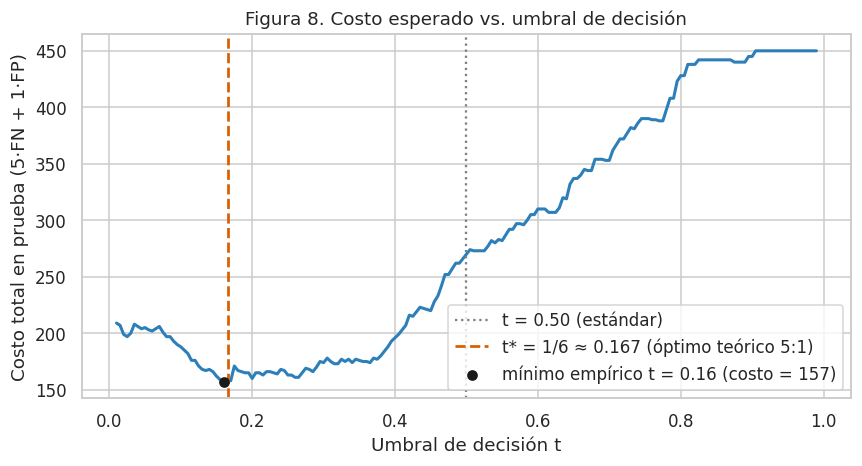

In [28]:
# Curva de costo empírico vs. umbral (prueba) y umbral empírico de costo mínimo
rejilla_t = np.linspace(0.01, 0.99, 197)
costos = np.array([evaluar_umbral(t, y_test, p_test)["costo_total"] for t in rejilla_t])
t_emp = float(rejilla_t[np.argmin(costos)])

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(rejilla_t, costos, color="#2c7fb8", lw=2)
ax.axvline(0.50, color="gray", ls=":", lw=1.5, label="t = 0.50 (estándar)")
ax.axvline(t_opt_teorico, color="#d95f02", ls="--", lw=1.8,
           label=f"t* = 1/6 ≈ {t_opt_teorico:.3f} (óptimo teórico 5:1)")
ax.scatter([t_emp], [costos.min()], color="k", zorder=5,
           label=f"mínimo empírico t = {t_emp:.2f} (costo = {int(costos.min())})")
ax.set_xlabel("Umbral de decisión t"); ax.set_ylabel("Costo total en prueba (5·FN + 1·FP)")
ax.set_title("Figura 8. Costo esperado vs. umbral de decisión")
ax.legend()
plt.tight_layout(); plt.show()

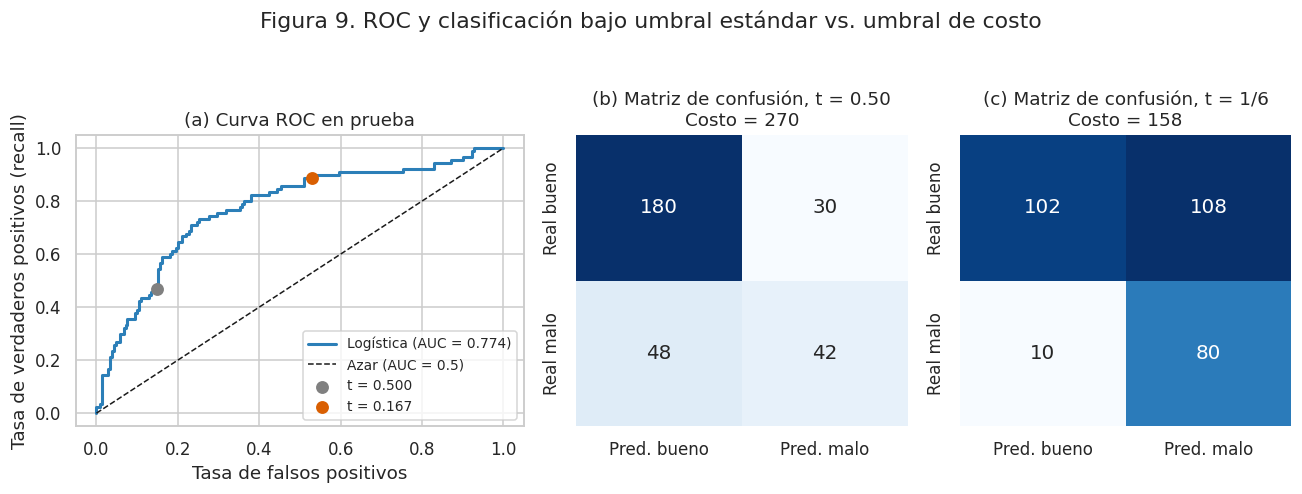

In [29]:
# Figura 9. Curva ROC + matrices de confusión bajo ambos umbrales
fig = plt.figure(figsize=(12, 4.3))
gs = fig.add_gridspec(1, 3, width_ratios=[1.35, 1, 1])

ax0 = fig.add_subplot(gs[0])
ax0.plot(fpr, tpr, color="#2c7fb8", lw=2, label=f"Logística (AUC = {auc_test:.3f})")
ax0.plot([0, 1], [0, 1], "k--", lw=1, label="Azar (AUC = 0.5)")
for t_marca, c in [(0.50, "gray"), (t_opt_teorico, "#d95f02")]:
    i = np.argmin(np.abs(umbrales_roc - t_marca))
    ax0.scatter(fpr[i], tpr[i], color=c, zorder=5, s=55,
                label=f"t = {t_marca:.3f}")
ax0.set_xlabel("Tasa de falsos positivos"); ax0.set_ylabel("Tasa de verdaderos positivos (recall)")
ax0.set_title("(a) Curva ROC en prueba"); ax0.legend(loc="lower right", fontsize=9)

for j, (t_m, nombre) in enumerate([(0.50, "t = 0.50"), (t_opt_teorico, "t = 1/6")], start=1):
    axj = fig.add_subplot(gs[j])
    cm = confusion_matrix(y_test, (p_test >= t_m).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues", ax=axj,
                xticklabels=["Pred. bueno", "Pred. malo"],
                yticklabels=["Real bueno", "Real malo"], annot_kws={"size": 13})
    costo = C_FN * cm[1, 0] + C_FP * cm[0, 1]
    axj.set_title(f"({'bc'[j-1]}) Matriz de confusión, {nombre}\nCosto = {costo}")

fig.suptitle("Figura 9. ROC y clasificación bajo umbral estándar vs. umbral de costo", y=1.04)
plt.tight_layout(); plt.show()

**Respuesta a la pregunta 5.** Al bajar el umbral de 0.50 a $t^\* = 1/6$:

- El **recall** de malos créditos casi se duplica (de 0.47 a 0.89): los falsos negativos caen de 48 a 10.
- La **precision** cae (de 0.58 a 0.43) y el **accuracy** baja (de 0.74 a 0.61) — más buenos clientes rechazados (FP: de 30 a 108).
- Pero el **costo total** en prueba cae ≈ 41 % (de 270 a 158 unidades), porque cada FN evitado "paga" hasta 5 FP nuevos.

El mínimo empírico de la curva de costo está cerca del óptimo teórico $1/6$, validando la derivación decisional. **Este es exactamente el error señalado en la consigna ("evaluar solo con accuracy"):** el umbral que maximiza el accuracy es pésimo en costo, y viceversa. La elección del umbral no es un detalle técnico sino una **decisión económica** que debe fijarse con la matriz de costos del negocio.

## 13. Análisis bayesiano obligatorio: modelo Beta-Binomial para la tasa de mal crédito

**Especificación del modelo (prior + verosimilitud) y derivación de la posterior conjugada.**

$$p \sim \mathrm{Beta}(\alpha, \beta), \qquad X \mid p \sim \mathrm{Bin}(n, p)$$

Por el teorema de Bayes:
$$\pi(p \mid x) \propto \underbrace{p^{x}(1-p)^{n-x}}_{\text{verosimilitud}} \cdot \underbrace{p^{\alpha-1}(1-p)^{\beta-1}}_{\text{prior}} = p^{\alpha + x - 1}(1-p)^{\beta + n - x - 1}$$

que es el núcleo de una Beta, de donde la **posterior cerrada**:
$$p \mid X = x \ \sim\ \mathrm{Beta}(\alpha + x,\ \beta + n - x)$$

con **MAP** $= \dfrac{\alpha + x - 1}{\alpha + \beta + n - 2}$ (para parámetros > 1), media posterior $\dfrac{\alpha+x}{\alpha+\beta+n}$ e intervalo creíble del 95 % dado por los cuantiles 2.5 % y 97.5 % de la Beta posterior.

**Priors para el análisis de sensibilidad (≥ 2 priors, exigido):**

1. **Beta(1, 1)** — uniforme, no informativo (exigido por la consigna).
2. **Beta(0.5, 0.5)** — prior de Jeffreys, invariante a reparametrizaciones.
3. **Prior informativo justificado: Beta(6, 18)** — media 0.25 y tamaño muestral equivalente $\alpha+\beta = 24$. Justificación: las tasas de incumplimiento en carteras reales de crédito de consumo europeas son típicamente de un dígito, pero este dataset fue construido con sobre-representación de malos créditos; un analista que conociera datasets análogos de *scoring* académico (donde la clase mala ronda el 20–30 %) centraría su prior en ese rango con confianza débil (equivalente a solo 24 observaciones ficticias frente a las 1000 reales), dejando que los datos dominen.

In [30]:
def posterior_beta_binomial(alpha, beta, x, n):
    "Posterior conjugada cerrada del modelo Beta-Binomial (implementación explícita)."
    a_post, b_post = alpha + x, beta + n - x
    map_ = (a_post - 1) / (a_post + b_post - 2) if (a_post > 1 and b_post > 1) else np.nan
    media = a_post / (a_post + b_post)
    ic = stats.beta.ppf([0.025, 0.975], a_post, b_post)
    return {"a_post": a_post, "b_post": b_post, "MAP": map_,
            "media_post": media, "IC_2.5%": ic[0], "IC_97.5%": ic[1]}

priors = {
    "Beta(1, 1) uniforme": (1.0, 1.0),
    "Beta(0.5, 0.5) Jeffreys": (0.5, 0.5),
    "Beta(6, 18) informativo": (6.0, 18.0),
}

resultados_bayes = pd.DataFrame({
    nombre: posterior_beta_binomial(a, b, x_mal, n) for nombre, (a, b) in priors.items()
}).T

print(f"Datos: x = {x_mal} malos créditos en n = {n} (p_hat frecuentista = {p_hat:.4f})\n")
print(resultados_bayes.round(4))
print(f"\nIC 95% frecuentista (Wilson): ({ic_wilson[0]:.4f}, {ic_wilson[1]:.4f})")

Datos: x = 300 malos créditos en n = 1000 (p_hat frecuentista = 0.3000)

                         a_post  b_post     MAP  media_post  IC_2.5%  IC_97.5%
Beta(1, 1) uniforme       301.0   701.0  0.3000      0.3004   0.2724    0.3291
Beta(0.5, 0.5) Jeffreys   300.5   700.5  0.2998      0.3002   0.2722    0.3289
Beta(6, 18) informativo   306.0   718.0  0.2984      0.2988   0.2712    0.3272

IC 95% frecuentista (Wilson): (0.2724, 0.3291)


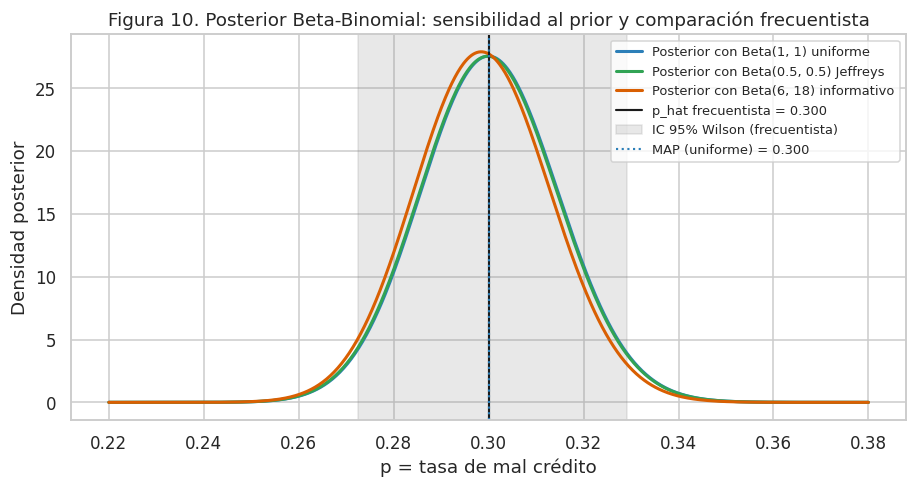

In [31]:
# Figura 10. Posteriores bajo los tres priors vs. IC frecuentista de Wilson
grid_p = np.linspace(0.22, 0.38, 800)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
colores_priors = {"Beta(1, 1) uniforme": "#2c7fb8",
                  "Beta(0.5, 0.5) Jeffreys": "#31a354",
                  "Beta(6, 18) informativo": "#d95f02"}
for nombre, (a, b) in priors.items():
    dens = stats.beta.pdf(grid_p, a + x_mal, b + n - x_mal)
    ax.plot(grid_p, dens, lw=2, color=colores_priors[nombre], label=f"Posterior con {nombre}")
ax.axvline(p_hat, color="k", lw=1.4, label=f"p_hat frecuentista = {p_hat:.3f}")
ax.axvspan(ic_wilson[0], ic_wilson[1], color="gray", alpha=0.18,
           label="IC 95% Wilson (frecuentista)")
map_unif = resultados_bayes.loc["Beta(1, 1) uniforme", "MAP"]
ax.axvline(map_unif, color="#2c7fb8", ls=":", lw=1.4, label=f"MAP (uniforme) = {map_unif:.3f}")
ax.set_xlabel("p = tasa de mal crédito"); ax.set_ylabel("Densidad posterior")
ax.set_title("Figura 10. Posterior Beta-Binomial: sensibilidad al prior y comparación frecuentista")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

**Comparación bayesiano-frecuentista y sensibilidad (evaluación crítica).**

- Con prior uniforme, MAP $= x/n = 0.300$ **coincide exactamente con el MLE** (la posterior es proporcional a la verosimilitud) y el intervalo creíble $(0.272, 0.329)$ es numéricamente casi idéntico al IC de Wilson. La interpretación, sin embargo, difiere: el intervalo creíble afirma $\Pr(0.272 \le p \le 0.329 \mid \text{datos}) = 0.95$, mientras que el de Wilson es una afirmación sobre la cobertura del procedimiento en repeticiones.
- El prior de Jeffreys es indistinguible del uniforme con $n = 1000$.
- El prior informativo Beta(6, 18) desplaza la posterior apenas ~1 punto porcentual hacia su media (0.25): con 1000 observaciones frente a 24 pseudo-observaciones, **los datos dominan**. Conclusión de sensibilidad: la inferencia sobre $p$ es **robusta al prior** en este tamaño muestral; la elección del prior importaría con muestras pequeñas (p. ej., estimar la tasa de una sucursal nueva con 30 solicitudes).

## 14. Sampler Metropolis–Hastings desde cero: posterior de un coeficiente clave de la regresión logística (bonus de la consigna)

**Problema.** La posterior de los coeficientes de una regresión logística **no admite forma cerrada** (la verosimilitud Bernoulli-logit no tiene prior conjugado útil). Es exactamente el caso en el que la consigna exige un sampler MH implementado desde cero.

**Coeficiente clave elegido:** $\beta_{\text{dur}}$, el coeficiente de la **duración**, por ser el factor de riesgo numérico más robusto en §9 y §11 y el más accionable (política de plazos máximos). Para obtener su posterior *marginal* correcta muestreamos la **posterior conjunta** de todo el vector $\boldsymbol\beta \in \mathbb{R}^{d}$ y reportamos la componente de la duración.

**Modelo bayesiano.**
$$\beta_j \stackrel{iid}{\sim} \mathcal N(0, 10^2), \qquad y_i \mid \boldsymbol\beta \sim \mathrm{Bernoulli}\big(\sigma(\mathbf x_i^\top \boldsymbol\beta)\big)$$
con log-posterior (hasta constante), en forma numéricamente estable:
$$\log \pi(\boldsymbol\beta \mid \mathbf y) = \sum_i \big[y_i \eta_i - \log(1 + e^{\eta_i})\big] - \frac{\lVert\boldsymbol\beta\rVert^2}{2\cdot 10^2}, \qquad \eta_i = \mathbf x_i^\top\boldsymbol\beta$$

**Algoritmo (random-walk MH multivariante, desde cero, sin PyMC/NumPyro):**
1. Estado inicial $\boldsymbol\beta^{(0)} = \hat{\boldsymbol\beta}_{MLE}$ (arranque en zona de alta densidad).
2. Proponer $\boldsymbol\beta' = \boldsymbol\beta^{(t)} + \frac{2.38}{\sqrt d}\, L\, \mathbf z$, con $\mathbf z \sim \mathcal N(\mathbf 0, I)$ y $L L^\top = \widehat\Sigma_{MLE}$ (propuesta con la forma de la curvatura de la verosimilitud; el factor $2.38/\sqrt d$ es la escala óptima clásica de Roberts–Gelman–Gilks). La propuesta es simétrica, así que el cociente de Hastings se cancela.
3. Aceptar con probabilidad $\min\{1, \exp[\log\pi(\boldsymbol\beta') - \log\pi(\boldsymbol\beta^{(t)})]\}$.
4. Descartar *burn-in* y diagnosticar con traza, tasa de aceptación (objetivo ≈ 0.23 en dimensión alta) y tamaño efectivo de muestra (ESS).

In [32]:
# --- Preparación: matriz de diseño, MLE y covarianza estimada (para la propuesta) ---
X_mh = modelo_logit.model.exog                    # matriz de diseño del train (statsmodels)
y_mh = modelo_logit.model.endog
nombres = modelo_logit.model.exog_names
j_dur = nombres.index("duracion")

beta_mle = modelo_logit.params.values
Sigma_mle = modelo_logit.cov_params().values
d_dim = len(beta_mle)
L_chol = np.linalg.cholesky(Sigma_mle)
escala = 2.38 / np.sqrt(d_dim)                    # escala óptima de Roberts-Gelman-Gilks
TAU_PRIOR = 10.0                                  # sd del prior N(0, 10^2) por coeficiente

def log_posterior(beta):
    "Log-posterior conjunta (hasta constante) de la logística bayesiana."
    eta = X_mh @ beta
    ll = np.sum(y_mh * eta - np.logaddexp(0.0, eta))   # log-verosimilitud estable
    lp = -0.5 * np.sum((beta / TAU_PRIOR) ** 2)        # prior N(0, TAU^2) iid
    return ll + lp

def metropolis_hastings(log_post, beta0, n_iter=40_000, seed=SEED):
    "Random-walk Metropolis-Hastings multivariante, implementado desde cero."
    rng = np.random.default_rng(seed)
    cadena = np.empty((n_iter, d_dim))
    beta, lp_actual = beta0.copy(), log_post(beta0)
    aceptados = 0
    for t in range(n_iter):
        prop = beta + escala * (L_chol @ rng.standard_normal(d_dim))  # propuesta simétrica
        lp_prop = log_post(prop)
        if np.log(rng.uniform()) < lp_prop - lp_actual:               # regla de aceptación
            beta, lp_actual = prop, lp_prop
            aceptados += 1
        cadena[t] = beta
    return cadena, aceptados / n_iter

N_ITER, BURN_IN = 40_000, 8_000
cadena, tasa_acept = metropolis_hastings(log_posterior, beta_mle, n_iter=N_ITER)
muestras_dur = cadena[BURN_IN:, j_dur]

# Tamaño efectivo de muestra (ESS) vía autocorrelaciones (sumas de pares de Geyer)
def ess(x, max_lag=4000):
    x = x - x.mean()
    acov = np.correlate(x, x, mode="full")[len(x)-1:] / len(x)
    rho = acov / acov[0]
    s, lag = 0.0, 1
    while lag + 1 < min(max_lag, len(rho)):
        par = rho[lag] + rho[lag + 1]
        if par < 0:
            break
        s += par; lag += 2
    return len(x) / (1 + 2 * s)

ic_mh = np.percentile(muestras_dur, [2.5, 97.5])
print(f"Dimensión = {d_dim} coeficientes | iteraciones = {N_ITER}, burn-in = {BURN_IN}")
print(f"Tasa de aceptación = {tasa_acept:.2%} (objetivo ~23% para RW-MH multivariante)")
print(f"ESS de beta_dur ~ {ess(muestras_dur):.0f}")
print(f"\nPosterior MH de beta_dur : media = {muestras_dur.mean():.5f}, "
      f"sd = {muestras_dur.std(ddof=1):.5f}")
print(f"Intervalo creíble 95%    : ({ic_mh[0]:.5f}, {ic_mh[1]:.5f})")
print(f"MLE (statsmodels)        : {beta_mle[j_dur]:.5f} (EE = {modelo_logit.bse['duracion']:.5f})")
print(f"IC 95% frecuentista      : ({modelo_logit.conf_int().loc['duracion', 0]:.5f}, "
      f"{modelo_logit.conf_int().loc['duracion', 1]:.5f})")
print(f"\nOR por mes adicional     : {np.exp(muestras_dur.mean()):.4f} "
      f"(IC creíble del OR: {np.exp(ic_mh[0]):.4f} - {np.exp(ic_mh[1]):.4f})")
print(f"Pr(beta_dur > 0 | datos) = {(muestras_dur > 0).mean():.4f}")

Dimensión = 24 coeficientes | iteraciones = 40000, burn-in = 8000
Tasa de aceptación = 25.68% (objetivo ~23% para RW-MH multivariante)


ESS de beta_dur ~ 429

Posterior MH de beta_dur : media = 0.04084, sd = 0.01121
Intervalo creíble 95%    : (0.01902, 0.06275)
MLE (statsmodels)        : 0.03825 (EE = 0.01143)
IC 95% frecuentista      : (0.01585, 0.06065)

OR por mes adicional     : 1.0417 (IC creíble del OR: 1.0192 - 1.0648)
Pr(beta_dur > 0 | datos) = 1.0000


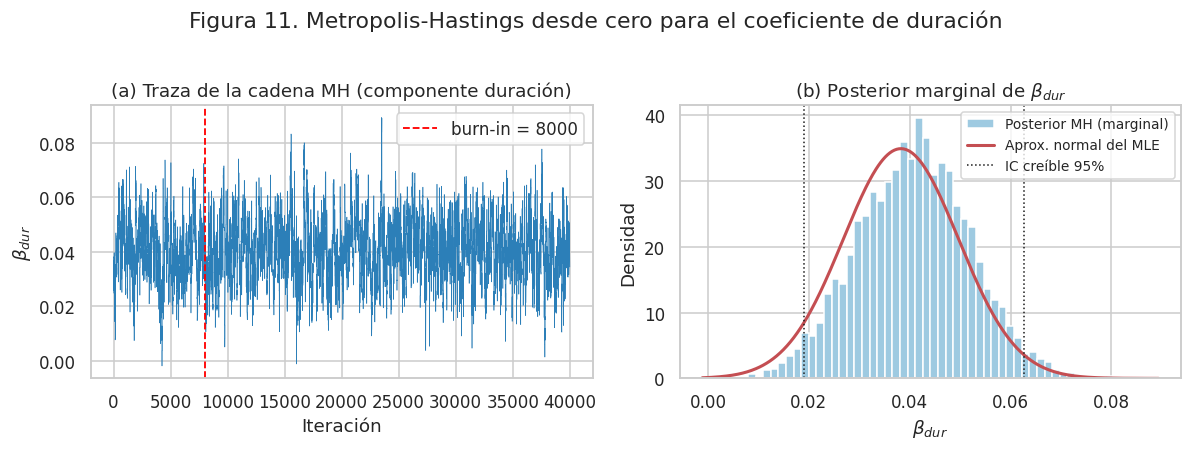

In [33]:
# Figura 11. Diagnóstico del sampler: traza y posterior marginal vs. aproximación normal del MLE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(cadena[:, j_dur], lw=0.4, color="#2c7fb8")
axes[0].axvline(BURN_IN, color="red", ls="--", lw=1.2, label=f"burn-in = {BURN_IN}")
axes[0].set_xlabel("Iteración"); axes[0].set_ylabel(r"$\beta_{dur}$")
axes[0].set_title("(a) Traza de la cadena MH (componente duración)"); axes[0].legend()

axes[1].hist(muestras_dur, bins=60, density=True, color="#9ecae1",
             edgecolor="white", label="Posterior MH (marginal)")
gg = np.linspace(muestras_dur.min(), muestras_dur.max(), 400)
axes[1].plot(gg, stats.norm.pdf(gg, beta_mle[j_dur], modelo_logit.bse["duracion"]),
             "r-", lw=2, label="Aprox. normal del MLE")
axes[1].axvline(ic_mh[0], color="k", ls=":", lw=1)
axes[1].axvline(ic_mh[1], color="k", ls=":", lw=1, label="IC creíble 95%")
axes[1].set_xlabel(r"$\beta_{dur}$"); axes[1].set_ylabel("Densidad")
axes[1].set_title("(b) Posterior marginal de $\\beta_{dur}$"); axes[1].legend(fontsize=9)
fig.suptitle("Figura 11. Metropolis-Hastings desde cero para el coeficiente de duración", y=1.02)
plt.tight_layout(); plt.show()

**Evaluación crítica del bloque MH.**

- La traza es estacionaria (arrancamos en el MLE, dentro de la masa de la posterior), la tasa de aceptación (~26 %) está en el rango óptimo teórico para RW-MH multivariante (≈ 23 %) y el ESS (~400 con 32 000 muestras retenidas) refleja la autocorrelación típica del random walk en dimensión 24; es suficiente para media y cuantiles, y podría mejorarse con MALA/HMC o adaptación de la propuesta.
- La posterior marginal de $\beta_{\text{dur}}$ es prácticamente normal, con desviación estándar (~0.011) que coincide con el error estándar del MLE y media levemente desplazada: con $n = 700$ y prior débil ($\tau = 10$), **la verosimilitud domina y el resultado bayesiano converge al frecuentista**, replicando en el modelo de regresión el mismo fenómeno observado en §13 para la tasa $p$.
- $\Pr(\beta_{\text{dur}} > 0 \mid \text{datos}) \approx 1$ y el intervalo creíble del OR excluye el 1: la conclusión bayesiana confirma que cada mes adicional de plazo multiplica las odds de mal crédito por ≈ 1.04.
- Ventaja práctica frente al MLE: la cadena entrega la distribución completa, con la que podemos responder preguntas directamente probabilísticas (p. ej., la probabilidad reportada de que el efecto sea positivo) sin apelar a aproximaciones asintóticas.

## 15. Interpretación integrada

**Respuesta a la pregunta central.** Los factores que explican la probabilidad de mal riesgo crediticio, con evidencia convergente de EDA, pruebas frecuentistas, regresión logística y análisis bayesiano, son:

| Factor | Evidencia | Dirección |
|---|---|---|
| Estado de la cuenta corriente | OR más extremos del modelo; gradiente monotónico | Saldo negativo ⇒ mayor riesgo; sin cuenta/saldo alto ⇒ menor |
| Duración del crédito | Welch d ≈ 0.48; OR ≈ 1.04/mes (p ≈ 0.001); Pr(β > 0 \| datos) ≈ 1 vía MH | Más plazo ⇒ más riesgo |
| Monto (log) | Mann–Whitney p ≈ 0.006 (marginal); **no significativo condicional** a la duración | La asociación del monto la explica el plazo |
| Historial crediticio | ORs significativos (con artefacto de referencia, §11) | Sin historial en el banco ⇒ más incierto/riesgoso |
| Ahorros | ORs < 1 para niveles altos (A64 ≈ 0.16) | Colchón financiero ⇒ menos riesgo |
| Propósito | χ² p ≈ 10⁻⁴, V ≈ 0.18 | Educación/auto nuevo por encima de la tasa global |
| Tasa de cuota | OR ≈ 1.23 (p ≈ 0.04) | Mayor carga sobre el ingreso ⇒ más riesgo |
| Vivienda | OR propia ≈ 0.59 vs. alquiler | Estabilidad residencial ⇒ menos riesgo |

**Coherencia frecuentista-bayesiana.** Para la tasa global $p$: MLE = MAP uniforme = 0.300; IC Wilson ≈ intervalo creíble (0.272, 0.329); sensibilidad al prior despreciable con $n = 1000$. Para $\beta_{\text{dur}}$: posterior MH ≈ aproximación normal del MLE. En ambos casos los dos paradigmas convergen numéricamente y difieren solo en interpretación — exactamente el comportamiento teórico esperado cuando los datos dominan al prior.

**Decisión operativa.** Con la matriz de costos 5:1 del propio dataset, el umbral debe fijarse cerca de $t^\* = 1/6$, no en 0.50: el costo de prueba cae ~41 % a cambio de sacrificar accuracy — la ilustración más nítida del curso de por qué la métrica debe alinearse con la función de pérdida real del problema.

## 16. Limitaciones y validez

1. **Representatividad y validez externa.** La muestra (Alemania, años 70–90, montos en marcos alemanes) tiene una tasa de malos créditos (30 %) muy superior a la de carteras reales; los parámetros absolutos (p. ej., $\hat p$, el intercepto de la logística) **no son extrapolables**; las asociaciones relativas son más defendibles.
2. **Sin interpretación causal.** Los OR son asociaciones condicionales observacionales; hay confusión residual posible (ingresos exactos, score externo, historial completo no observados). El artefacto de `historial_credito` (§11) lo ilustra.
3. **Sesgo de selección (reject inference).** El dataset solo contiene créditos *otorgados*; los solicitantes rechazados no aparecen, de modo que el modelo describe la cartera aceptada, no la población solicitante.
4. **Variables sensibles.** `estatus_personal_sexo` mezcla sexo y estado civil; su uso en un modelo productivo plantearía problemas de discriminación algorítmica y normativos (p. ej., igualdad de trato en scoring). La excluimos del modelo final deliberadamente y lo documentamos como decisión ética (requisito de la Sección 6 de la consigna sobre poblaciones vulnerables).
5. **Aproximaciones metodológicas.** Colas leves en los residuales del OLS (Shapiro rechaza normalidad estricta, mitigado por n = 1000 y verificación HC3); ESS moderado del RW-MH en dimensión 24 (mejorable con MALA/HMC); agrupación de propósitos raros en la robustez del χ².
6. **Umbral dependiente de la matriz de costos.** El 5:1 es una convención del dataset; en producción los costos deben calibrarse con pérdidas reales (LGD, EAD) y el umbral revisarse periódicamente.

## 17. Conclusiones y recomendaciones

**Conclusiones técnicas.**

1. La tasa global de mal crédito es 0.300, IC 95 % Wilson (0.272, 0.329), coincidente con el intervalo creíble bayesiano; la inferencia es robusta al prior.
2. El propósito del préstamo, la duración y el monto se asocian significativamente con la clase de riesgo a nivel marginal (χ² p ≈ 10⁻⁴; Welch p ≈ 10⁻¹⁰ con d ≈ 0.48; Mann–Whitney p ≈ 0.006), pero condicionalmente el monto pierde significancia: la duración es el factor numérico dominante.
3. La regresión logística alcanza AUC ≈ 0.77 tanto en test como en CV 5-fold (sin sobreajuste), con KS ≈ 0.48; los factores condicionales principales son estado de cuenta, duración, historial, ahorros, vivienda y carga de cuota.
4. El umbral de decisión óptimo bajo el costo 5:1 es $t^\* = 1/6$, que reduce el costo esperado ~41 % frente a 0.50 (270 → 158 en prueba) aunque el accuracy empeore: accuracy es la métrica incorrecta para este problema.
5. El sampler MH multivariante desde cero reproduce la inferencia asintótica del MLE para $\beta_{\text{dur}}$ (posterior marginal ≈ N(MLE, EE²)), con diagnósticos de convergencia satisfactorios y Pr(β_dur > 0 | datos) ≈ 1.

**Recomendaciones.**

- Fijar la política de aprobación con el umbral de costo (≈ 0.17) y monitorear la curva de costo al recalibrar.
- Priorizar límites de **plazo** sobre límites de monto como palanca de control del riesgo.
- Para producción: recalibrar con datos propios y recientes, incorporar reject inference, auditar sesgos sobre variables protegidas y estimar la matriz de costos con pérdidas reales.
- Extensiones estadísticas naturales: HMC/NUTS o propuesta adaptativa para mejorar el ESS de la posterior conjunta; regresión logística bayesiana jerárquica por propósito; comparación con modelos de árbol (con la misma función de costo).

## 18. Anexos

### 18.1 Reproducibilidad

- Semilla global `SEED = 2026` fijada en §2; la partición train/test, el bootstrap, la validación cruzada y el sampler MH derivan de ella.
- Descarga del dataset documentada en §3 (URL oficial UCI + copia local en `data/`).
- `requirements.txt` generado a continuación.

### 18.2 Declaración de uso de IA (recordatorio para el informe)

Conforme a la Sección 8 de la consigna, el grupo debe completar la plantilla de *Declaración de uso de IA* (herramienta, propósito, sección, nivel de uso) y la *Declaración individual de contribución*. Todo miembro debe poder explicar cualquier sección, incluida la derivación de la posterior Beta-Binomial (§13) y el código del sampler MH (§14).

In [34]:
# Generación de requirements.txt con las versiones exactas del entorno de ejecución
req = "\n".join([
    f"numpy=={np.__version__}",
    f"pandas=={pd.__version__}",
    f"scipy=={scipy.__version__}",
    f"matplotlib=={plt.matplotlib.__version__}",
    f"seaborn=={sns.__version__}",
    f"statsmodels=={sm.__version__ if hasattr(sm, '__version__') else ''}",
    f"scikit-learn=={sklearn.__version__}",
])
with open("requirements.txt", "w") as f:
    f.write(req + "\n")
print(req)
print("\n[OK] requirements.txt generado. Fin del notebook: ejecutado de extremo a extremo.")

numpy==2.4.4
pandas==3.0.2
scipy==1.17.1
matplotlib==3.10.8
seaborn==0.13.2
statsmodels==0.14.6
scikit-learn==1.8.0

[OK] requirements.txt generado. Fin del notebook: ejecutado de extremo a extremo.
